In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 2. Generate Synthetic Dataset
np.random.seed(42)

# Group A (Control): Mean purchase of $80, standard deviation of $15
group_a_purchases = np.random.normal(loc=80, scale=15, size=250)

# Group B (Treatment): Mean purchase of $83.5, standard deviation of $16
group_b_purchases = np.random.normal(loc=83.5, scale=16, size=250)

# Create a DataFrame
df = pd.DataFrame({
    'group': ['Group A'] * 250 + ['Group B'] * 250,
    'purchase_amount': np.concatenate([group_a_purchases, group_b_purchases])
})

display(df.head())
display(df.groupby('group').describe())

,group,purchase_amount
0,Group A,87.450712
1,Group A,77.926035
2,Group A,89.715328
3,Group A,102.845448
4,Group A,76.487699


purchase_amount                                              \
                  count       mean        std        min        25%   
group                                                                 
Group A           250.0  79.963656  14.490805  40.703823  69.811264   
Group B           250.0  83.757582  15.969177  31.639723  72.209064   

                                           
               50%        75%         max  
group                                      
Group A  80.888292  88.742982  137.790972  
Group B  83.478168  94.362126  132.762093

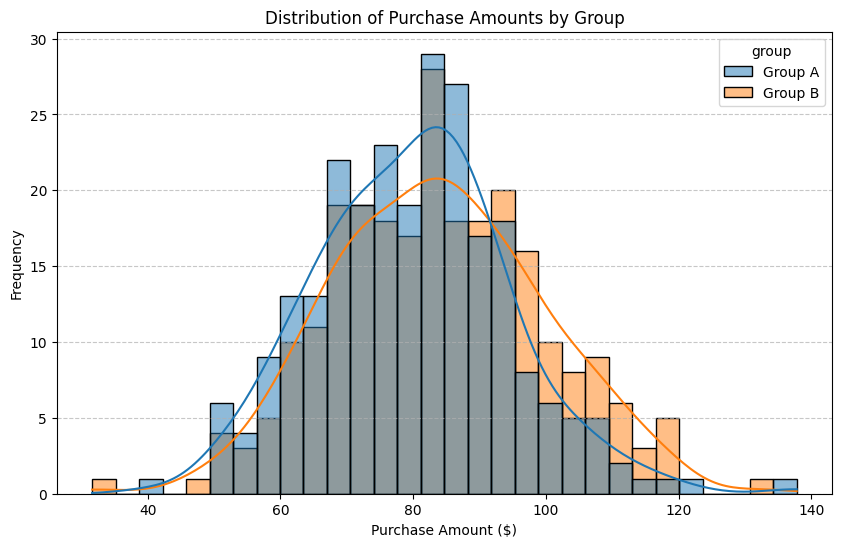

In [ ]:
# 3. Visualize the Distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='purchase_amount', hue='group', kde=True, bins=30, alpha=0.5)
plt.title('Distribution of Purchase Amounts by Group')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

t_stat, p_val = stats.ttest_ind(group_a_purchases, group_b_purchases, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")


alpha = 0.05
if p_val < alpha:
    print(f"\nReject the null hypothesis (p < {alpha}). There is a statistically significant difference in average order values between Group A and Group B.")
else:
    print(f"\nFail to reject the null hypothesis (p >= {alpha}). There is no statistically significant difference in average order values between Group A and Group B.")

t-statistic: -2.7818
p-value: 0.0056

Reject the null hypothesis (p < 0.05). There is a statistically significant difference in average order values between Group A and Group B.
